In [2]:
%pip install torch pillow transformers==4.50 accelerate pandas huggingface_hub

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import re
import time
import math
import torch
import pandas as pd
from PIL import Image
from huggingface_hub import snapshot_download
from transformers import AutoProcessor, AutoModelForVision2Seq

/opt/conda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

print("Loading processor...")
processor = AutoProcessor.from_pretrained(model_id)

dtype = torch.float16 if torch.cuda.is_available() else torch.float32

print("Loading model...")
model = AutoModelForVision2Seq.from_pretrained(
    model_id,
    torch_dtype=dtype,
    device_map="auto"
)

print("Done.")
print("CUDA available:", torch.cuda.is_available())
print("Model device:", model.device)

Loading processor...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.50, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loading model...


Loading checkpoint shards: 100%|██████████| 2/2 [00:34<00:00, 17.13s/it]

Done.
CUDA available: False
Model device: cpu


In [5]:
local_dir = snapshot_download(
    repo_id="ReadingTimeMachine/visual_qa_histograms",
    repo_type="dataset",
    allow_patterns=["example_hists_larger/**"]
)

print("local_dir:", local_dir)

img_dir = os.path.join(local_dir, "example_hists_larger", "imgs")
print("img_dir:", img_dir)
print("First few files:", os.listdir(img_dir)[:5])

Fetching 1002 files: 100%|██████████| 1002/1002 [00:00<00:00, 2056.53it/s]


local_dir: /home/zoyalou2/.cache/huggingface/hub/datasets--ReadingTimeMachine--visual_qa_histograms/snapshots/f7ba35f3751cf2b27c943ccb1d313424897c913b
img_dir: /home/zoyalou2/.cache/huggingface/hub/datasets--ReadingTimeMachine--visual_qa_histograms/snapshots/f7ba35f3751cf2b27c943ccb1d313424897c913b/example_hists_larger/imgs
First few files: ['id_000000.jpeg', 'id_000001.jpeg', 'id_000002.jpeg', 'id_000003.jpeg', 'id_000004.jpeg']


In [6]:
df = pd.read_csv("hist_larger_parsed.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(500, 7)
['image_path', 'nbars', 'minimum', 'maximum', 'median', 'mean', 'ngaussians']


,image_path,nbars,minimum,maximum,median,mean,ngaussians
0,visual_qa_histograms/example_hists_larger/imag...,45,-0.904726,0.696466,-0.390822,-0.206333,4
1,visual_qa_histograms/example_hists_larger/imag...,10,-0.591920,-0.276302,-0.452123,-0.446007,2
2,visual_qa_histograms/example_hists_larger/imag...,60,-0.666776,-0.072680,-0.281081,-0.305015,4
3,visual_qa_histograms/example_hists_larger/imag...,45,-0.304668,0.579063,0.297337,0.254717,2
4,visual_qa_histograms/example_hists_larger/imag...,20,-0.688649,-0.617108,-0.629551,-0.636472,2


In [7]:
def csv_path_to_img_filename(path_value: str) -> str:
    """
    Convert CSV image_path to actual image filename in imgs/.
    Expected actual files look like: id_000000.jpeg
    """
    fname = os.path.basename(str(path_value))
    match = re.search(r"(\d+)", fname)
    if match is None:
        return None
    num = match.group(1)
    return f"id_{num}.jpeg"

df["image_file"] = df["image_path"].apply(csv_path_to_img_filename)
df["full_image_path"] = df["image_file"].apply(
    lambda x: os.path.join(img_dir, x) if pd.notna(x) else None
)
df["exists"] = df["full_image_path"].apply(
    lambda p: os.path.exists(p) if isinstance(p, str) else False
)

print(df["exists"].value_counts(dropna=False))
df_valid = df[df["exists"]].copy()
print("Valid rows:", df_valid.shape)
df_valid[["image_path", "image_file", "full_image_path"]].head()

exists
True    500
Name: count, dtype: int64
Valid rows: (500, 10)


,image_path,image_file,full_image_path
0,visual_qa_histograms/example_hists_larger/imag...,id_000000.jpeg,/home/zoyalou2/.cache/huggingface/hub/datasets...
1,visual_qa_histograms/example_hists_larger/imag...,id_000001.jpeg,/home/zoyalou2/.cache/huggingface/hub/datasets...
2,visual_qa_histograms/example_hists_larger/imag...,id_000002.jpeg,/home/zoyalou2/.cache/huggingface/hub/datasets...
3,visual_qa_histograms/example_hists_larger/imag...,id_000003.jpeg,/home/zoyalou2/.cache/huggingface/hub/datasets...
4,visual_qa_histograms/example_hists_larger/imag...,id_000004.jpeg,/home/zoyalou2/.cache/huggingface/hub/datasets...


Testing image: /home/zoyalou2/.cache/huggingface/hub/datasets--ReadingTimeMachine--visual_qa_histograms/snapshots/f7ba35f3751cf2b27c943ccb1d313424897c913b/example_hists_larger/imgs/id_000000.jpeg


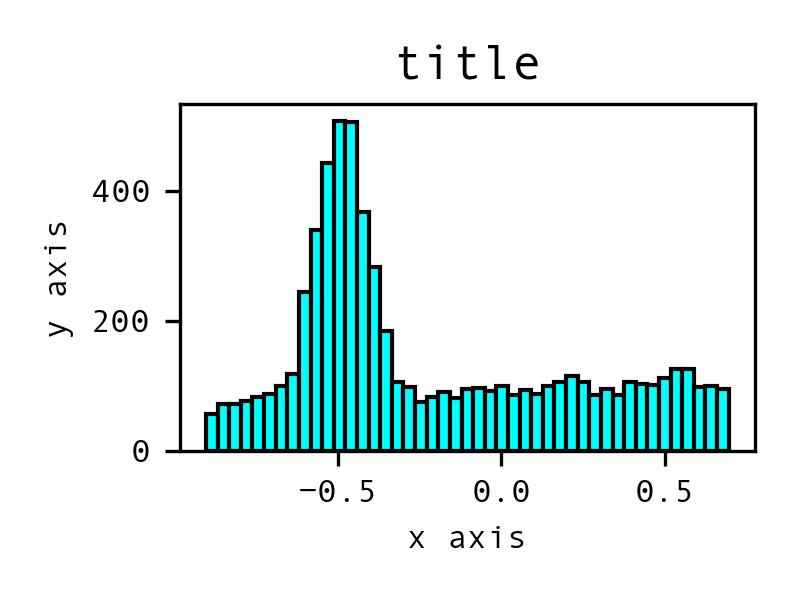

In [8]:
row = df_valid.iloc[0]
print("Testing image:", row["full_image_path"])

image = Image.open(row["full_image_path"]).convert("RGB")
image

In [9]:
PROMPTS = {
    "zero_shot": lambda stat: (
        f"What is the {stat} of this histogram? "
        f"Answer with a single number if possible."
    ),

    "structured": lambda stat: (
        f"What is the {stat} of this histogram? "
        f"Read the x-axis carefully. If the exact value is not explicitly labeled, "
        f"estimate it from the histogram shape and axis scale. "
        f"Answer with a single number."
    ),

    "chain_of_thought": lambda stat: (
        f"What is the {stat} of this histogram? "
        f"First identify the x-axis range, then locate where the {stat} should be on the histogram, "
        f"then estimate its value. "
        f"At the end, give a single final numeric answer."
    ),
}

In [10]:
def ask_model(image, question, max_new_tokens=60):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": question},
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = processor(
        text=text,
        images=image,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(model.device) if hasattr(v, "to") else v
        for k, v in inputs.items()
    }

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens
        )

    input_len = inputs["input_ids"].shape[1]
    generated_ids = output_ids[0][input_len:]
    output_text = processor.decode(generated_ids, skip_special_tokens=True)
    return output_text.strip()

In [11]:
def extract_first_number(text):
    if text is None:
        return None

    text = str(text).replace(",", "")
    matches = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", text)

    if not matches:
        return None

    try:
        return float(matches[0])
    except ValueError:
        return None

In [12]:
def compute_metrics(pred, gt, min_val, max_val):
    if pred is None or pd.isna(gt):
        return {
            "absolute_error": None,
            "relative_error": None,
            "range_normalized_error": None,
        }

    absolute_error = abs(pred - gt)

    relative_error = None
    if gt != 0:
        relative_error = absolute_error / abs(gt)

    value_range = max_val - min_val
    range_normalized_error = None
    if value_range != 0:
        range_normalized_error = absolute_error / abs(value_range)

    return {
        "absolute_error": absolute_error,
        "relative_error": relative_error,
        "range_normalized_error": range_normalized_error,
    }

In [13]:
row = df_valid.iloc[0]
image = Image.open(row["full_image_path"]).convert("RGB")

stat = "median"
question = PROMPTS["zero_shot"](stat)

print("Question:", question)
print("Ground truth:", row[stat])

start = time.time()
output = ask_model(image, question)
elapsed = time.time() - start

pred = extract_first_number(output)

metrics = compute_metrics(
    pred=pred,
    gt=row[stat],
    min_val=row["minimum"],
    max_val=row["maximum"]
)

print("Model output:", output)
print("Predicted number:", pred)
print("Elapsed seconds:", elapsed)
print(metrics)

Question: What is the median of this histogram? Answer with a single number if possible.
Ground truth: -0.390821709483618
Model output: 0
Predicted number: 0.0
Elapsed seconds: 108.86189198493958
{'absolute_error': np.float64(0.390821709483618), 'relative_error': np.float64(1.0), 'range_normalized_error': np.float64(0.2440817164811511)}


In [14]:
row = df_valid.iloc[0]
image = Image.open(row["full_image_path"]).convert("RGB")

stat = "median"
prompt_type = "zero_shot"
question = PROMPTS[prompt_type](stat)

start = time.time()
output_text = ask_model(image, question, max_new_tokens=30)
elapsed = time.time() - start

pred = extract_first_number(output_text)
metrics = compute_metrics(
    pred=pred,
    gt=row[stat],
    min_val=row["minimum"],
    max_val=row["maximum"]
)

print("image:", row["image_file"])
print("stat:", stat)
print("prompt:", prompt_type)
print("ground truth:", row[stat])
print("model output:", output_text)
print("predicted:", pred)
print("elapsed:", elapsed)
print(metrics)

image: id_000000.jpeg
stat: median
prompt: zero_shot
ground truth: -0.390821709483618
model output: 0
predicted: 0.0
elapsed: 104.21462726593018
{'absolute_error': np.float64(0.390821709483618), 'relative_error': np.float64(1.0), 'range_normalized_error': np.float64(0.2440817164811511)}


In [15]:
row = df_valid.iloc[0]
image = Image.open(row["full_image_path"]).convert("RGB")
stat = "median"

results = []

for prompt_type, prompt_fn in PROMPTS.items():
    question = prompt_fn(stat)

    start = time.time()
    output_text = ask_model(image, question, max_new_tokens=30)
    elapsed = time.time() - start

    pred = extract_first_number(output_text)
    metrics = compute_metrics(
        pred=pred,
        gt=row[stat],
        min_val=row["minimum"],
        max_val=row["maximum"]
    )

    results.append({
        "image_file": row["image_file"],
        "stat": stat,
        "prompt_type": prompt_type,
        "ground_truth": row[stat],
        "model_output": output_text,
        "predicted_value": pred,
        "elapsed_seconds": elapsed,
        **metrics
    })

results_df = pd.DataFrame(results)
results_df

,image_file,stat,prompt_type,ground_truth,model_output,predicted_value,elapsed_seconds,absolute_error,relative_error,range_normalized_error
0,id_000000.jpeg,median,zero_shot,-0.390822,0,0.0,105.486981,0.390822,1.000000,0.244082
1,id_000000.jpeg,median,structured,-0.390822,0.0,0.0,116.197805,0.390822,1.000000,0.244082
2,id_000000.jpeg,median,chain_of_thought,-0.390822,The x-axis range is from approximately -0.6 to...,-0.6,201.498457,0.209178,0.535227,0.130639


In [16]:
sample_size = 3
stats_to_test = ["median"]

sample_df = df_valid.head(sample_size).copy()
results = []

for idx, row in sample_df.iterrows():
    image = Image.open(row["full_image_path"]).convert("RGB")

    for stat in stats_to_test:
        for prompt_type, prompt_fn in PROMPTS.items():
            question = prompt_fn(stat)

            try:
                start = time.time()
                output_text = ask_model(image, question, max_new_tokens=30)
                elapsed = time.time() - start

                pred = extract_first_number(output_text)
                metrics = compute_metrics(
                    pred=pred,
                    gt=row[stat],
                    min_val=row["minimum"],
                    max_val=row["maximum"]
                )

                results.append({
                    "row_index": idx,
                    "image_file": row["image_file"],
                    "stat": stat,
                    "prompt_type": prompt_type,
                    "ground_truth": row[stat],
                    "model_output": output_text,
                    "predicted_value": pred,
                    "elapsed_seconds": elapsed,
                    **metrics
                })

                print(f"done: {row['image_file']} | {prompt_type} | pred={pred}")

            except Exception as e:
                results.append({
                    "row_index": idx,
                    "image_file": row["image_file"],
                    "stat": stat,
                    "prompt_type": prompt_type,
                    "ground_truth": row[stat],
                    "model_output": f"ERROR: {e}",
                    "predicted_value": None,
                    "elapsed_seconds": None,
                    "absolute_error": None,
                    "relative_error": None,
                    "range_normalized_error": None,
                })
                print(f"error: {row['image_file']} | {prompt_type} | {e}")

results_df = pd.DataFrame(results)
results_df

done: id_000000.jpeg | zero_shot | pred=0.0
done: id_000000.jpeg | structured | pred=0.0
done: id_000000.jpeg | chain_of_thought | pred=-0.6
done: id_000001.jpeg | zero_shot | pred=-0.45
done: id_000001.jpeg | structured | pred=-0.45
done: id_000001.jpeg | chain_of_thought | pred=-0.6
done: id_000002.jpeg | zero_shot | pred=-0.35
done: id_000002.jpeg | structured | pred=-0.35
done: id_000002.jpeg | chain_of_thought | pred=-0.6


,row_index,image_file,stat,prompt_type,ground_truth,model_output,predicted_value,elapsed_seconds,absolute_error,relative_error,range_normalized_error
0,0,id_000000.jpeg,median,zero_shot,-0.390822,0,0.00,103.553645,0.390822,1.000000,0.244082
1,0,id_000000.jpeg,median,structured,-0.390822,0.0,0.00,111.299850,0.390822,1.000000,0.244082
2,0,id_000000.jpeg,median,chain_of_thought,-0.390822,The x-axis range is from approximately -0.6 to...,-0.60,200.103737,0.209178,0.535227,0.130639
3,1,id_000001.jpeg,median,zero_shot,-0.452123,-0.45,-0.45,118.178070,0.002123,0.004695,0.006725
4,1,id_000001.jpeg,median,structured,-0.452123,-0.45,-0.45,121.906833,0.002123,0.004695,0.006725
5,1,id_000001.jpeg,median,chain_of_thought,-0.452123,The x-axis range is from -0.6 to -0.3.\n\nTo f...,-0.60,218.005870,0.147877,0.327074,0.468534
6,2,id_000002.jpeg,median,zero_shot,-0.281081,-0.35,-0.35,118.187086,0.068919,0.245193,0.116007
7,2,id_000002.jpeg,median,structured,-0.281081,-0.35,-0.35,121.203884,0.068919,0.245193,0.116007
8,2,id_000002.jpeg,median,chain_of_thought,-0.281081,The x-axis range is approximately from -0.6 to...,-0.60,196.588909,0.318919,1.134616,0.536814


In [17]:
summary = (
    results_df
    .groupby("prompt_type")
    .agg(
        mean_abs_error=("absolute_error", "mean"),
        mean_norm_error=("range_normalized_error", "mean"),
        numeric_response_rate=("predicted_value", lambda s: s.notna().mean())
    )
    .reset_index()
    .sort_values("mean_norm_error")
)

summary

,prompt_type,mean_abs_error,mean_norm_error,numeric_response_rate
1,structured,0.153954,0.122271,1.0
2,zero_shot,0.153954,0.122271,1.0
0,chain_of_thought,0.225325,0.378662,1.0


In [18]:
overall = (
    results_df
    .groupby("prompt_type", dropna=False)
    .agg(
        n=("predicted_value", "size"),
        numeric_response_rate=("predicted_value", lambda s: s.notna().mean()),
        mean_absolute_error=("absolute_error", "mean"),
        mean_relative_error=("relative_error", "mean"),
        mean_range_normalized_error=("range_normalized_error", "mean"),
    )
    .reset_index()
    .sort_values("mean_range_normalized_error")
)

overall

,prompt_type,n,numeric_response_rate,mean_absolute_error,mean_relative_error,mean_range_normalized_error
1,structured,3,1.0,0.153954,0.416629,0.122271
2,zero_shot,3,1.0,0.153954,0.416629,0.122271
0,chain_of_thought,3,1.0,0.225325,0.665639,0.378662


In [19]:
for _, r in results_df.head(10).iterrows():
    print("IMAGE:", r["image_file"])
    print("STAT:", r["stat"])
    print("PROMPT:", r["prompt_type"])
    print("GROUND TRUTH:", r["ground_truth"])
    print("MODEL OUTPUT:", r["model_output"])
    print("PREDICTED VALUE:", r["predicted_value"])
    print("ABS ERROR:", r["absolute_error"])
    print("RANGE-NORMALIZED ERROR:", r["range_normalized_error"])
    print("-" * 80)

IMAGE: id_000000.jpeg
STAT: median
PROMPT: zero_shot
GROUND TRUTH: -0.390821709483618
MODEL OUTPUT: 0
PREDICTED VALUE: 0.0
ABS ERROR: 0.390821709483618
RANGE-NORMALIZED ERROR: 0.2440817164811511
--------------------------------------------------------------------------------
IMAGE: id_000000.jpeg
STAT: median
PROMPT: structured
GROUND TRUTH: -0.390821709483618
MODEL OUTPUT: 0.0
PREDICTED VALUE: 0.0
ABS ERROR: 0.390821709483618
RANGE-NORMALIZED ERROR: 0.2440817164811511
--------------------------------------------------------------------------------
IMAGE: id_000000.jpeg
STAT: median
PROMPT: chain_of_thought
GROUND TRUTH: -0.390821709483618
MODEL OUTPUT: The x-axis range is from approximately -0.6 to 0.6. The median should be around the center of this range, which is
PREDICTED VALUE: -0.6
ABS ERROR: 0.20917829051638198
RANGE-NORMALIZED ERROR: 0.1306390995200627
--------------------------------------------------------------------------------
IMAGE: id_000001.jpeg
STAT: median
PROMPT: zer

In [20]:
sample_size = 10
stats_to_test = ["median"]

sample_df = df_valid.sample(sample_size, random_state=42).copy()
results = []

for idx, row in sample_df.iterrows():
    image = Image.open(row["full_image_path"]).convert("RGB")

    for stat in stats_to_test:
        gt = row[stat]

        for prompt_type, prompt_fn in PROMPTS.items():
            question = prompt_fn(stat)

            try:
                start = time.time()
                output_text = ask_model(image, question, max_new_tokens=20)
                elapsed = time.time() - start

                pred = extract_first_number(output_text)
                metrics = compute_metrics(
                    pred=pred,
                    gt=gt,
                    min_val=row["minimum"],
                    max_val=row["maximum"]
                )

                results.append({
                    "row_index": idx,
                    "image_file": row["image_file"],
                    "stat": stat,
                    "prompt_type": prompt_type,
                    "ground_truth": gt,
                    "model_output": output_text,
                    "predicted_value": pred,
                    "elapsed_seconds": elapsed,
                    **metrics
                })

                print(f"done: {row['image_file']} | {prompt_type} | pred={pred}")

            except Exception as e:
                print(f"error: {row['image_file']} | {prompt_type}: {e}")

results_df = pd.DataFrame(results)

done: id_000361.jpeg | zero_shot | pred=0.45
done: id_000361.jpeg | structured | pred=0.45
done: id_000361.jpeg | chain_of_thought | pred=0.2
done: id_000073.jpeg | zero_shot | pred=0.75
done: id_000073.jpeg | structured | pred=0.75
done: id_000073.jpeg | chain_of_thought | pred=0.6
done: id_000374.jpeg | zero_shot | pred=0.0
done: id_000374.jpeg | structured | pred=0.0
done: id_000374.jpeg | chain_of_thought | pred=-0.5
done: id_000155.jpeg | zero_shot | pred=0.825
done: id_000155.jpeg | structured | pred=0.825
done: id_000155.jpeg | chain_of_thought | pred=0.75
done: id_000104.jpeg | zero_shot | pred=0.325
done: id_000104.jpeg | structured | pred=0.325
done: id_000104.jpeg | chain_of_thought | pred=0.31
done: id_000394.jpeg | zero_shot | pred=-0.7
done: id_000394.jpeg | structured | pred=-0.7
done: id_000394.jpeg | chain_of_thought | pred=-0.8
done: id_000377.jpeg | zero_shot | pred=100.0
done: id_000377.jpeg | structured | pred=0.5
done: id_000377.jpeg | chain_of_thought | pred=-0.5

In [21]:
def label_quality(rne):
    if pd.isna(rne):
        return "no numeric answer"
    elif rne < 0.05:
        return "very accurate"
    elif rne < 0.15:
        return "reasonable"
    elif rne < 0.30:
        return "poor"
    else:
        return "incorrect"

results_df["quality_label"] = results_df["range_normalized_error"].apply(label_quality)

quality_summary = (
    results_df
    .groupby(["prompt_type", "stat", "quality_label"])
    .size()
    .reset_index(name="count")
)

quality_summary

,prompt_type,stat,quality_label,count
0,chain_of_thought,median,incorrect,7
1,chain_of_thought,median,poor,3
2,structured,median,incorrect,1
3,structured,median,poor,1
4,structured,median,reasonable,5
5,structured,median,very accurate,3
6,zero_shot,median,incorrect,1
7,zero_shot,median,poor,1
8,zero_shot,median,reasonable,5
9,zero_shot,median,very accurate,3
